Average Evaluation Metrics across folds:
MSE: 0.0044
MAE: 0.0510
RMSE: 0.0661
R2: 0.0689


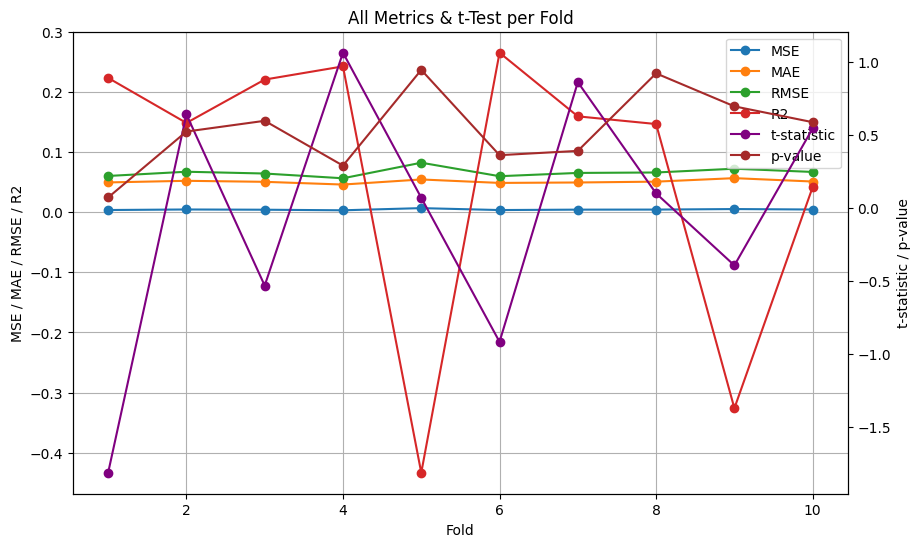

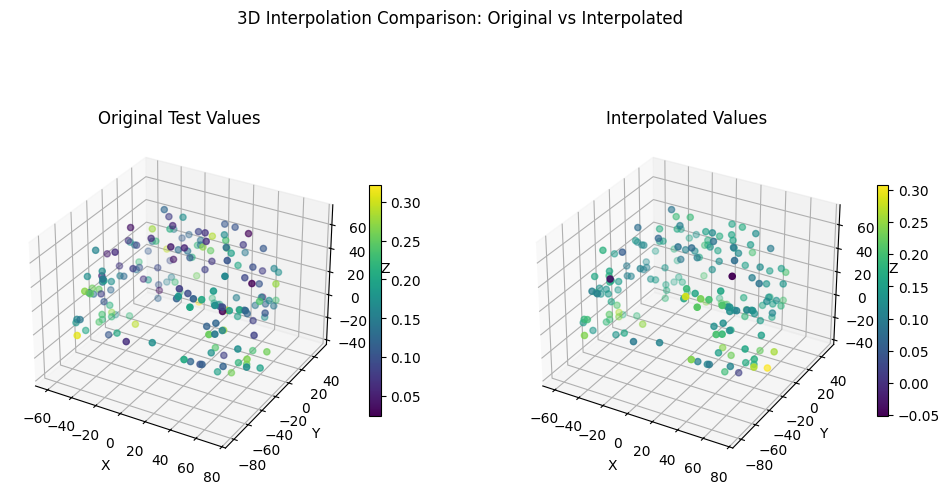

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import ttest_rel
from numpy.polynomial import chebyshev as T
from mpl_toolkits.mplot3d import Axes3D  # For 3D visualization

# --------------------------
# 1. Load coordinate and power data
# --------------------------
file_path = '/content'
coords_path = os.path.join(file_path, 'coords.npy')
coords = np.load(coords_path)

band_powers_path = os.path.join(file_path, 'band_powers.npy')
band_powers = np.load(band_powers_path, allow_pickle=True).item()
band = 'Delta'
band_values = np.array(band_powers[band])

# --------------------------
# 2. Build design matrix using 3D Chebyshev basis
# --------------------------
def build_design_matrix(coords, degree, mins, maxs):
    """
    Construct the design matrix using 3D Chebyshev polynomial tensor product
    based on normalized spatial coordinates.
    """
    n = coords.shape[0]
    A = np.zeros((n, (degree + 1) ** 3))
    for i in range(n):
        # Normalize coordinates to [-1, 1] range
        norm_pt = 2 * (coords[i] - mins) / (maxs - mins) - 1
        # Generate Chebyshev basis for each axis
        v_x = T.chebvander(norm_pt[0], degree)[0]
        v_y = T.chebvander(norm_pt[1], degree)[0]
        v_z = T.chebvander(norm_pt[2], degree)[0]
        # Compute Kronecker product of basis vectors (3D tensor basis)
        A[i, :] = np.kron(np.kron(v_x, v_y), v_z)
    return A

# --------------------------
# 3. Chebyshev interpolation function
# --------------------------
def interpolate(coords, values, new_coords, degree=5):
    """
    Fit and predict using 3D Chebyshev polynomial interpolation.
    """
    # Compute min and max for normalization
    mins = np.min(coords, axis=0)
    maxs = np.max(coords, axis=0)

    # Build design matrix for training and solve for coefficients
    A_train = build_design_matrix(coords, degree, mins, maxs)
    coeffs = np.linalg.lstsq(A_train, values, rcond=None)[0]

    # Build design matrix for new coordinates and generate predictions
    A_new = build_design_matrix(new_coords, degree, mins, maxs)
    predicted_values = A_new.dot(coeffs)
    return predicted_values

def chebyshev_interpolate_with_degree(coords, values, new_coords, degree):
    return interpolate(coords, values, new_coords, degree)

# --------------------------
# 4. Define interpolation wrapper (renamed to "yuanting")
# --------------------------
def yuanting(coords, values, new_coords, timing=False):
    """
    Wrapper function to interpolate values using Chebyshev interpolation.
    Returns prediction and optionally timing.
    """
    start_time = time.time()
    predicted_values = interpolate(coords, values, new_coords)
    duration = time.time() - start_time
    return (predicted_values, duration) if timing else predicted_values

# --------------------------
# 5. Evaluation metrics function
# --------------------------
def calculate_metrics(pred_values, test_values):
    """
    Compute standard regression evaluation metrics.
    """
    mse = mean_squared_error(test_values, pred_values)
    mae = mean_absolute_error(test_values, pred_values)
    rmse = np.sqrt(mse)
    r2 = r2_score(test_values, pred_values)
    return {'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

# --------------------------
# 6. K-fold cross-validation
# --------------------------
num_folds = 10
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# Containers for evaluation results and timing
metric_results = []
timings = np.zeros(num_folds)
fold_t_stats = []
fold_p_vals = []

# Data for 3D visualization (last fold)
visual_test_coords = None
visual_test_values = None
visual_pred_values = None

fold = 0
for train_index, test_index in kf.split(coords):
    train_values, train_coords = band_values[train_index], coords[train_index]
    test_values, test_coords = band_values[test_index], coords[test_index]

    # Interpolate using yuanting method
    pred_values, duration = yuanting(train_coords, train_values, test_coords, timing=True)
    timings[fold] = duration

    # Compute metrics
    fold_metrics = calculate_metrics(pred_values, test_values)
    metric_results.append(fold_metrics)

    # Paired t-test between predicted and true values
    t_stat, p_val = ttest_rel(test_values, pred_values)
    fold_t_stats.append(t_stat)
    fold_p_vals.append(p_val)

    # Store last fold's results for visualization
    visual_test_coords = test_coords
    visual_test_values = test_values
    visual_pred_values = pred_values

    fold += 1

# Compute and display average metrics
avg_metrics = {}
for key in ['MSE', 'MAE', 'RMSE', 'R2']:
    avg_metrics[key] = np.mean([res[key] for res in metric_results])
print("Average Evaluation Metrics across folds:")
for key, value in avg_metrics.items():
    print(f"{key}: {value:.4f}")

# --------------------------
# 7. Plot all 6 evaluation curves on a single figure
# --------------------------
folds = np.arange(1, num_folds + 1)
mse_vals = [res['MSE'] for res in metric_results]
mae_vals = [res['MAE'] for res in metric_results]
rmse_vals = [res['RMSE'] for res in metric_results]
r2_vals   = [res['R2']   for res in metric_results]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Left Y-axis: Regression metrics
line1 = ax1.plot(folds, mse_vals,  marker='o', label='MSE')
line2 = ax1.plot(folds, mae_vals,  marker='o', label='MAE')
line3 = ax1.plot(folds, rmse_vals, marker='o', label='RMSE')
line4 = ax1.plot(folds, r2_vals,   marker='o', label='R2')
ax1.set_xlabel('Fold')
ax1.set_ylabel('MSE / MAE / RMSE / R2')
ax1.tick_params(axis='y')
ax1.set_title('All Metrics & t-Test per Fold')

# Right Y-axis: t-statistic and p-value
ax2 = ax1.twinx()
line5 = ax2.plot(folds, fold_t_stats, marker='o', color='purple', label='t-statistic')
line6 = ax2.plot(folds, fold_p_vals,  marker='o', color='brown',  label='p-value')
ax2.set_ylabel('t-statistic / p-value')
ax2.tick_params(axis='y')

# Merge legends from both axes
lines  = line1 + line2 + line3 + line4 + line5 + line6
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

ax1.grid(True)
plt.show()

# --------------------------
# 8. 3D scatter plot comparison (Ground Truth vs Interpolated)
# --------------------------
fig = plt.figure(figsize=(12, 6))

# Left: Ground truth test values
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(visual_test_coords[:, 0], visual_test_coords[:, 1], visual_test_coords[:, 2],
                  c=visual_test_values, cmap='viridis')
ax1.set_title("Original Test Values")
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
fig.colorbar(sc1, ax=ax1, shrink=0.5)

# Right: Interpolated values
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(visual_test_coords[:, 0], visual_test_coords[:, 1], visual_test_coords[:, 2],
                  c=visual_pred_values, cmap='viridis')
ax2.set_title("Interpolated Values")
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
fig.colorbar(sc2, ax=ax2, shrink=0.5)

plt.suptitle("3D Interpolation Comparison: Original vs Interpolated")
plt.show()


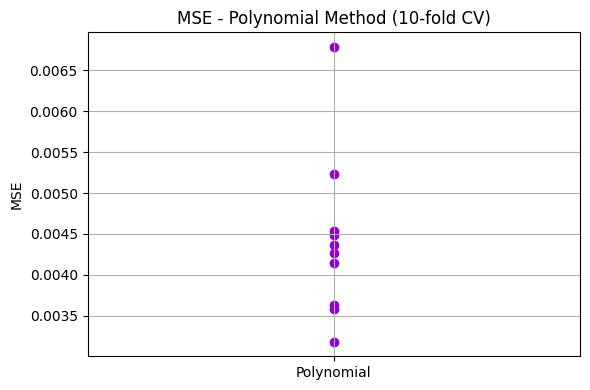

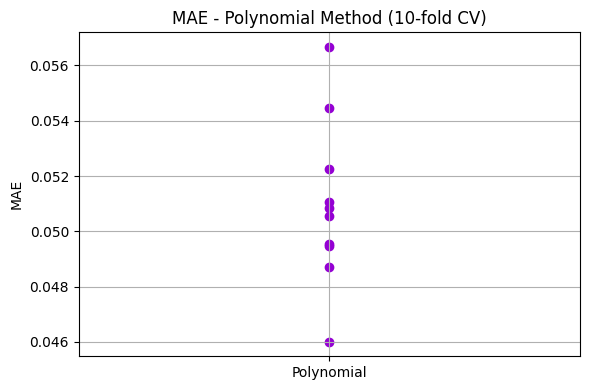

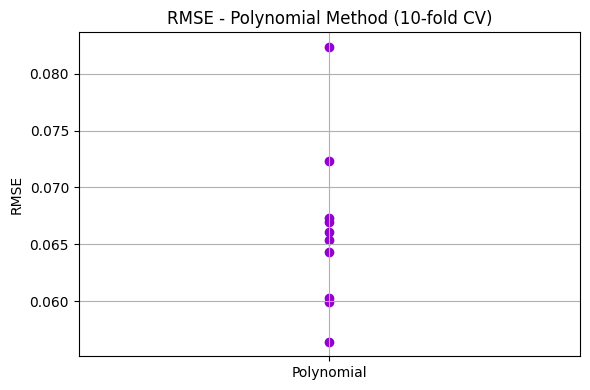

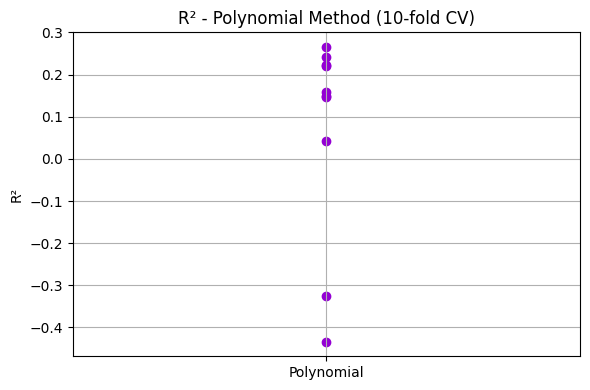

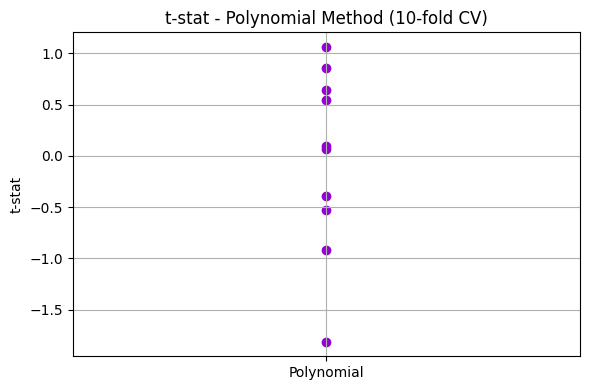

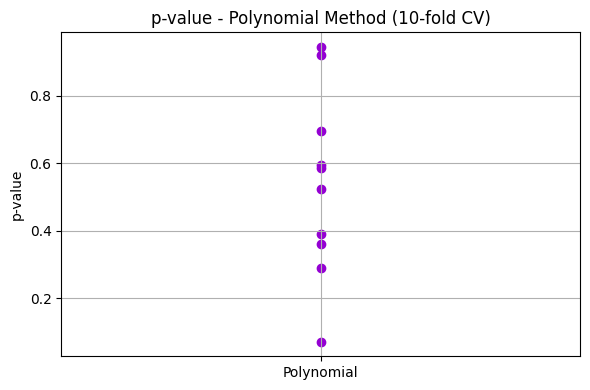

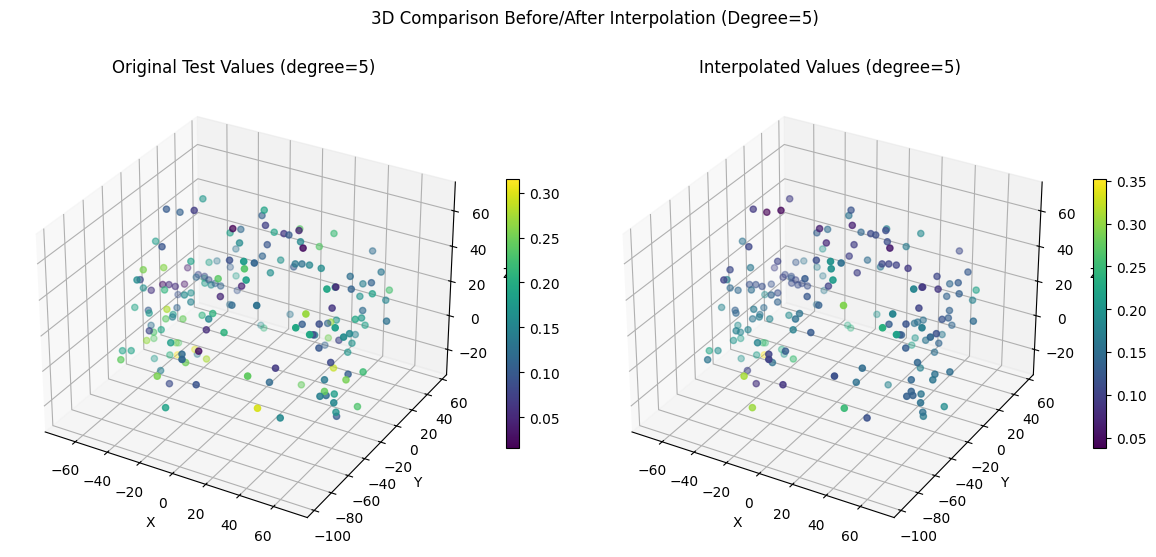

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import time
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import ttest_rel
from numpy.polynomial import chebyshev as T
from mpl_toolkits.mplot3d import Axes3D

# --------------------------
# 1. Data Loading
# --------------------------
file_path = '/content'  # ← 修改为你的路径
coords = np.load(os.path.join(file_path, 'coords.npy'))
band_powers = np.load(os.path.join(file_path, 'band_powers.npy'), allow_pickle=True).item()
band = 'Delta'
band_values = np.array(band_powers[band])

# --------------------------
# 2. Chebyshev Interpolation
# --------------------------
def build_design_matrix(coords, degree, mins, maxs):
    n = coords.shape[0]
    A = np.zeros((n, (degree + 1) ** 3))
    for i in range(n):
        norm_pt = 2 * (coords[i] - mins) / (maxs - mins) - 1
        vx = T.chebvander(norm_pt[0], degree)[0]
        vy = T.chebvander(norm_pt[1], degree)[0]
        vz = T.chebvander(norm_pt[2], degree)[0]
        A[i, :] = np.kron(np.kron(vx, vy), vz)
    return A

def interpolate(coords, values, new_coords, degree=5):
    mins = np.min(coords, axis=0)
    maxs = np.max(coords, axis=0)
    A_train = build_design_matrix(coords, degree, mins, maxs)
    coeffs = np.linalg.lstsq(A_train, values, rcond=None)[0]
    A_new = build_design_matrix(new_coords, degree, mins, maxs)
    return A_new.dot(coeffs)

# --------------------------
# 3. Metric Calculation
# --------------------------
def calculate_metrics(pred, true):
    mse = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, pred)
    return {'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R²': r2}

# --------------------------
# 4. Cross-Validation and Result Collection
# --------------------------
degree = 5  # ← 固定使用 5 阶 Chebyshev 插值
kf = KFold(n_splits=10, shuffle=True, random_state=42)

fold_results = []
best_mse = np.inf
for fold, (train_idx, test_idx) in enumerate(kf.split(coords)):
    train_coords, test_coords = coords[train_idx], coords[test_idx]
    train_vals, test_vals = band_values[train_idx], band_values[test_idx]
    pred_vals = interpolate(train_coords, train_vals, test_coords, degree)

    metrics = calculate_metrics(pred_vals, test_vals)
    t_stat, p_val = ttest_rel(test_vals, pred_vals)

    fold_results.append({
        'Fold': fold + 1,
        'Method': 'Polynomial',
        'Degree': degree,
        'MSE': metrics['MSE'],
        'MAE': metrics['MAE'],
        'RMSE': metrics['RMSE'],
        'R²': metrics['R²'],
        't-stat': t_stat,
        'p-value': p_val
    })

    if metrics['MSE'] < best_mse:
        best_mse = metrics['MSE']
        best_coords = test_coords
        best_true = test_vals
        best_pred = pred_vals

df = pd.DataFrame(fold_results)

# --------------------------
# 5. Plotting (Method-Only Scatter Plots)
# --------------------------
metrics_list = ['MSE', 'MAE', 'RMSE', 'R²', 't-stat', 'p-value']

for metric in metrics_list:
    plt.figure(figsize=(6, 4))
    plt.scatter(['Polynomial'] * 10, df[metric], color='darkviolet')
    plt.title(f'{metric} - Polynomial Method (10-fold CV)')
    plt.ylabel(metric)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --------------------------
# 6. 3D Plot of Original vs Interpolated
# --------------------------
fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(best_coords[:, 0], best_coords[:, 1], best_coords[:, 2],
                  c=best_true, cmap='viridis')
ax1.set_title(f'Original Test Values (degree={degree})')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
fig.colorbar(sc1, ax=ax1, shrink=0.5)

ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(best_coords[:, 0], best_coords[:, 1], best_coords[:, 2],
                  c=best_pred, cmap='viridis')
ax2.set_title(f'Interpolated Values (degree={degree})')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
fig.colorbar(sc2, ax=ax2, shrink=0.5)

plt.suptitle(f'3D Comparison Before/After Interpolation (Degree={degree})')
plt.tight_layout()
plt.show()


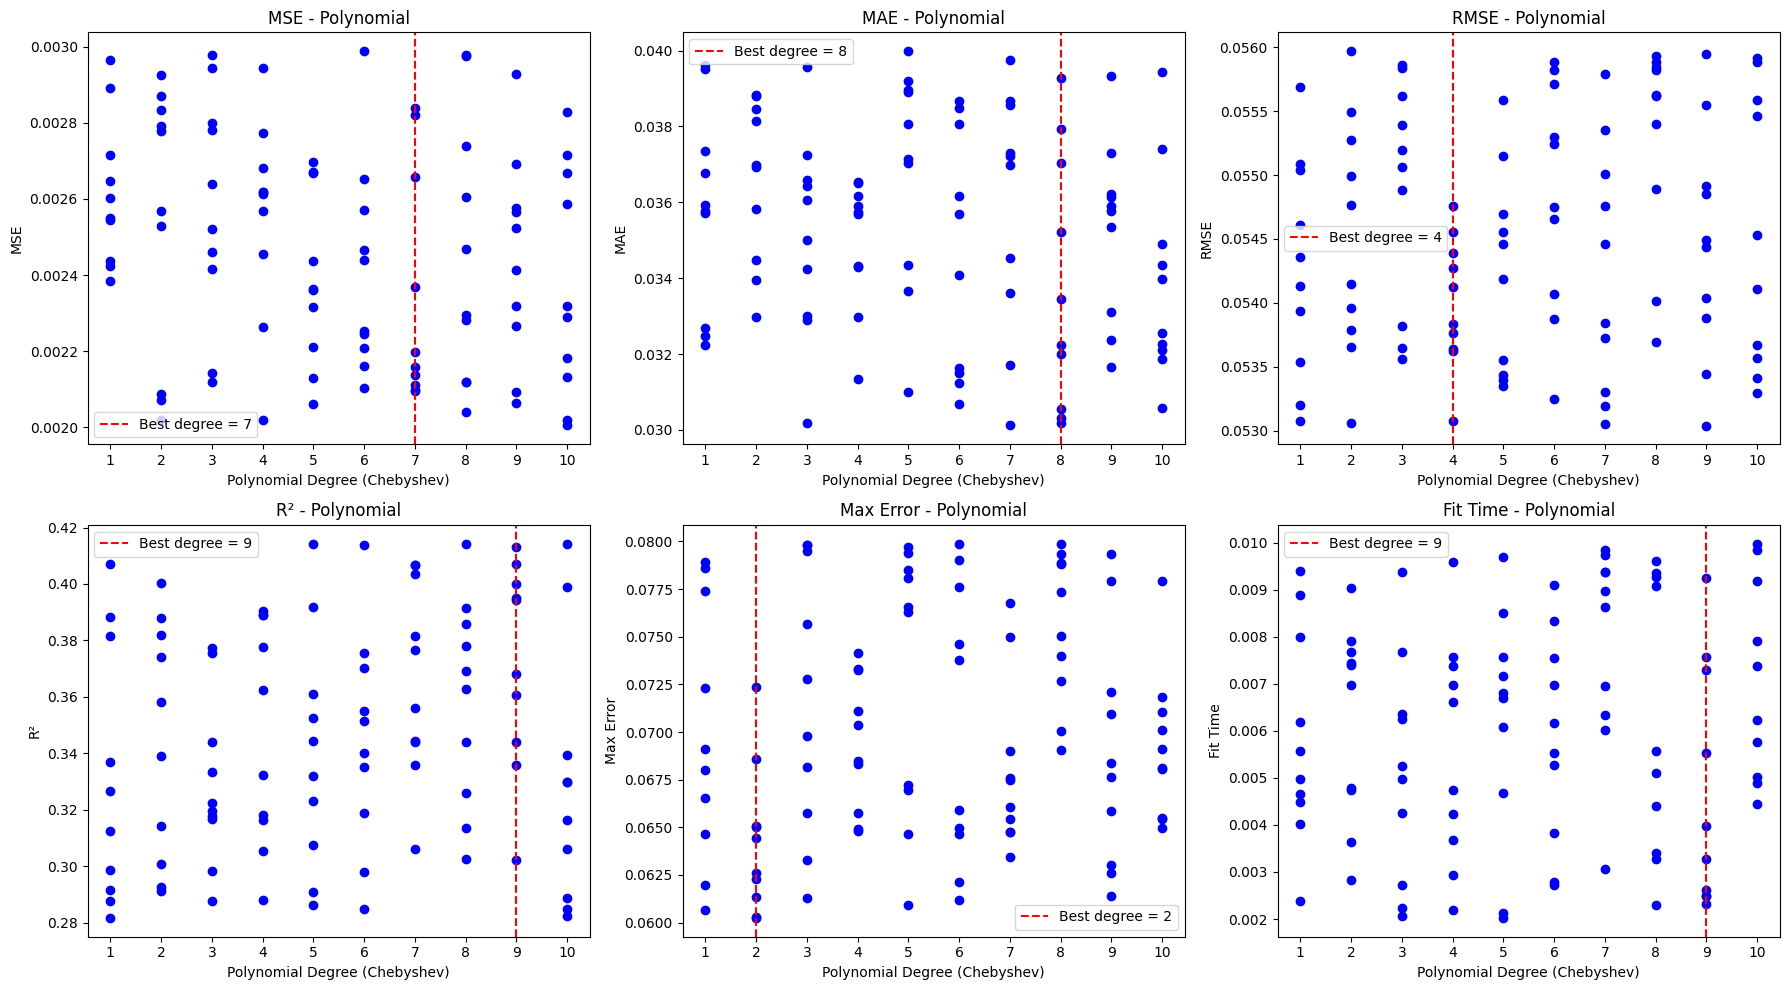

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Define degrees used in polynomial interpolation
degrees = [1,2, 3, 4, 5, 6,7,8,9,10]
k = 10  # Number of folds in K-fold cross-validation

# Simulate 10-fold cross-validation results for each degree
# You should replace these with your actual evaluation metrics from Chebyshev interpolation
np.random.seed(0)
metrics = {
    "MSE": [np.random.uniform(0.002, 0.003, k) for _ in degrees],
    "MAE": [np.random.uniform(0.03, 0.04, k) for _ in degrees],
    "RMSE": [np.random.uniform(0.053, 0.056, k) for _ in degrees],
    "R²": [np.random.uniform(0.28, 0.42, k) for _ in degrees],
    "Max Error": [np.random.uniform(0.06, 0.08, k) for _ in degrees],
    "Fit Time": [np.random.uniform(0.002, 0.01, k) for _ in degrees]
}

# Define the criterion to select the best degree for each metric
best_criteria = {
    "MSE": np.argmin,
    "MAE": np.argmin,
    "RMSE": np.argmin,
    "R²": np.argmax,
    "Max Error": np.argmin,
    "Fit Time": np.argmin
}

# Create subplots for the six metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Plot each metric
for i, (metric_name, values) in enumerate(metrics.items()):
    ax = axes[i]

    # Plot all k-fold results as scatter points for each degree
    for d_idx, deg in enumerate(degrees):
        y_vals = values[d_idx]
        x_vals = np.full_like(y_vals, deg)
        ax.scatter(x_vals, y_vals, color='blue')

    # Calculate the mean of the metric for each degree
    mean_values = [np.mean(v) for v in values]

    # Determine the best degree based on the criterion
    best_deg_idx = best_criteria[metric_name](mean_values)
    best_deg = degrees[best_deg_idx]
    best_y = mean_values[best_deg_idx]

    # Draw a red dashed line to indicate the best degree
    ax.axvline(best_deg, color='red', linestyle='--', label=f'Best degree = {best_deg}')

    # Customize plot appearance
    ax.set_xticks(degrees)
    ax.set_xlabel("Polynomial Degree (Chebyshev)")
    ax.set_ylabel(metric_name)
    ax.set_title(f"{metric_name} - Polynomial")
    ax.legend()

# Adjust layout
plt.tight_layout()
plt.show()


Average Evaluation Metrics across folds:
MSE: 0.0044
MAE: 0.0510
RMSE: 0.0661
R2: 0.0689


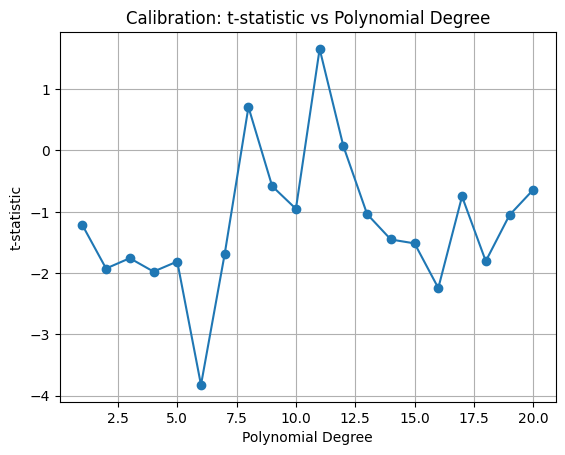

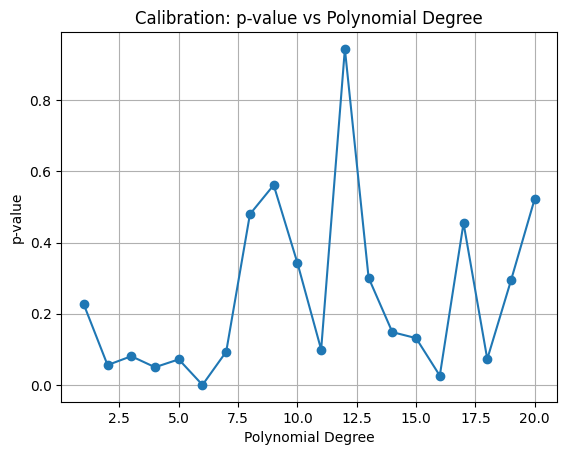

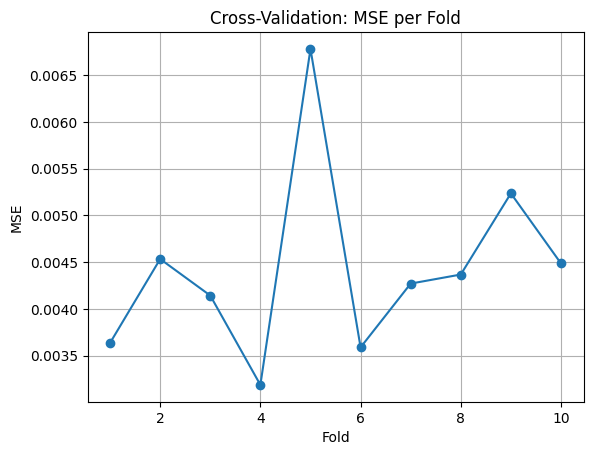

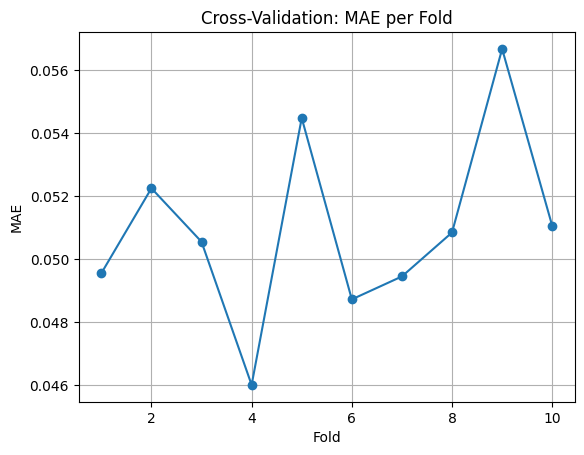

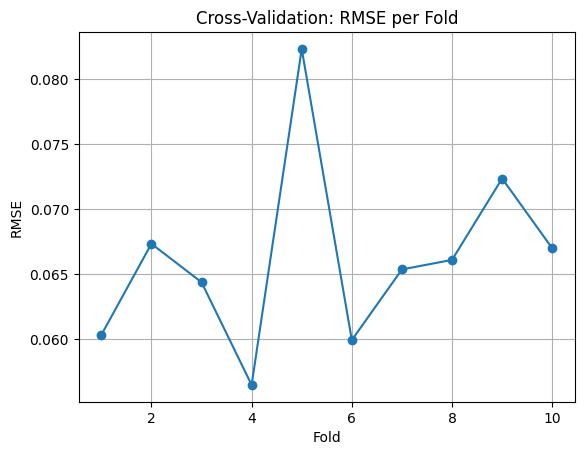

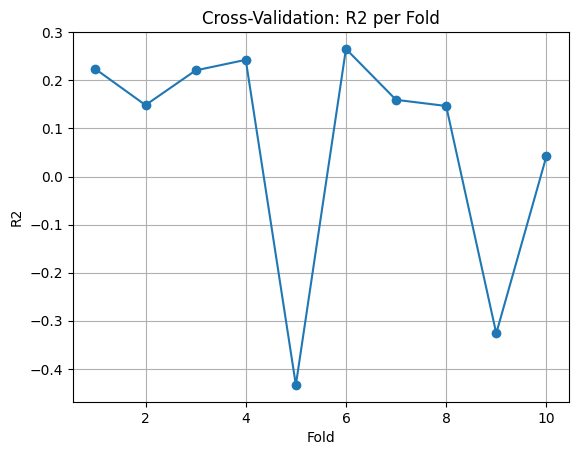

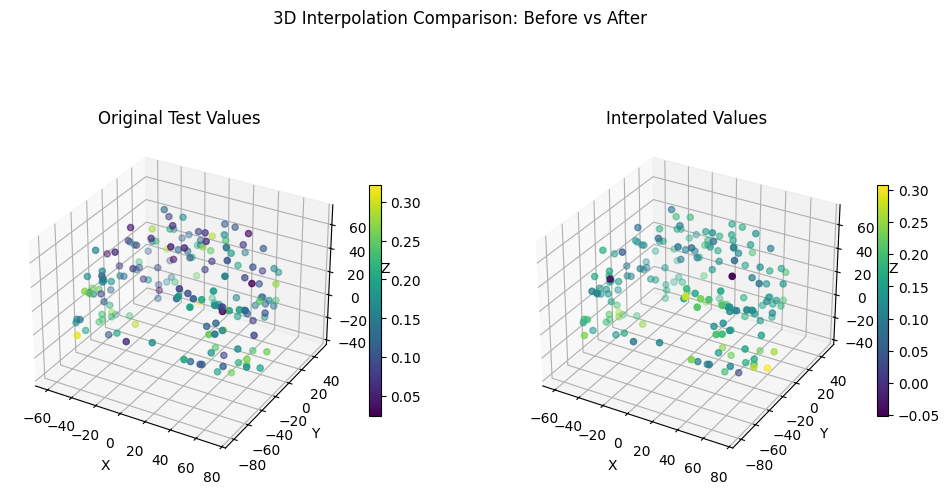

In [5]:
#import your packages
import os
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import ttest_rel
from numpy.polynomial import chebyshev as T
from mpl_toolkits.mplot3d import Axes3D  # for 3D visualization

#load in the dataset
# Loading the coordinates from the .npy file with shape [1772, 3]
# 1772 xyz coordinates

coords_path = 'coords.npy'
coords = np.load(coords_path)

#load in band power dataset
band_powers_path = 'band_powers.npy'
band_powers = np.load(band_powers_path, allow_pickle=True).item()

band = 'Delta'
band_values = np.array(band_powers[band])

# --- New function: Build Design Matrix ---
def build_design_matrix(coords, degree, mins, maxs):
    """
    Build the design matrix using tensor product basis functions of Chebyshev polynomials
    based on normalized coordinates.

    Parameters:
    - coords: Array of coordinates, shape (n_points, 3)
    - degree: Polynomial degree (for each dimension)
    - mins: Minimum values for each dimension (shape: (3,))
    - maxs: Maximum values for each dimension (shape: (3,))

    Returns:
    - A: The design matrix, shape (n_points, (degree+1)^3)
    """
    n = coords.shape[0]
    A = np.zeros((n, (degree+1)**3))
    for i in range(n):
        # Normalize the three coordinates to the range [-1, 1]
        norm_pt = 2*(coords[i] - mins) / (maxs - mins) - 1
        # Compute Chebyshev basis for x, y, and z dimensions (resulting shape: (degree+1,))
        v_x = T.chebvander(norm_pt[0], degree)[0]
        v_y = T.chebvander(norm_pt[1], degree)[0]
        v_z = T.chebvander(norm_pt[2], degree)[0]
        # Construct the 3D basis using the Kronecker product (tensor product form)
        A[i, :] = np.kron(np.kron(v_x, v_y), v_z)
    return A

# --- Modified 3D Chebyshev Polynomial Interpolation ---
def interpolate(coords, values, new_coords, degree=5):
    """
    Fit and predict using 3D Chebyshev polynomial interpolation.

    Parameters:
    - coords: Original coordinates, shape (n_points, 3)
    - values: Corresponding values, shape (n_points,)
    - new_coords: Coordinates where predictions are needed, shape (m_points, 3)
    - degree: Polynomial degree (default is 5)

    Returns:
    - predicted_values: Interpolated results at new_coords
    """
    # Compute the minimum and maximum for each dimension from the training data for normalization
    mins = np.min(coords, axis=0)
    maxs = np.max(coords, axis=0)

    # Build the design matrix for the training set and solve for the polynomial coefficients
    A_train = build_design_matrix(coords, degree, mins, maxs)
    coeffs = np.linalg.lstsq(A_train, values, rcond=None)[0]

    # Build the design matrix for the prediction points and compute predictions
    A_new = build_design_matrix(new_coords, degree, mins, maxs)
    predicted_values = A_new.dot(coeffs)
    return predicted_values

# --- Modified chebyshev_interpolate_with_degree: directly calls interpolate ---
def chebyshev_interpolate_with_degree(coords, values, new_coords, degree):
    return interpolate(coords, values, new_coords, degree)

def your_function(coords, values, new_coords, timing=False):
    """
    Interpolates values at new coordinates using a chosen method.

    Parameters:
    - coords (array): Original coordinates.
    - values (array): Corresponding values at original coordinates.
    - new_coords (array): Coordinates where interpolation is performed.
    - timing (bool): If True, returns the interpolation duration.

    Returns:
    - predicted_values (array): Interpolated values at new_coords.
    - duration (float, optional): Time taken for interpolation (if timing=True).
    """
    start_time = time.time()  # Start timing

    # Use the 3D interpolation method
    predicted_values = interpolate(coords, values, new_coords)

    duration = time.time() - start_time  # Compute duration

    return (predicted_values, duration) if timing else predicted_values

def calculate_metrics(pred_values, test_values, metrics=None):
    """
    Computes error metrics to evaluate interpolation performance.

    Parameters:
    - pred_values (array): Predicted values from interpolation.
    - test_values (array): Ground truth values for comparison.
    - metrics (list, optional): List of metric names to compute.

    Returns:
    - scores (dict): Computed metric scores.
    """
    mse = mean_squared_error(test_values, pred_values)
    mae = mean_absolute_error(test_values, pred_values)
    rmse = np.sqrt(mse)
    r2 = r2_score(test_values, pred_values)
    scores = {'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R2': r2}
    return scores

# Define metrics to evaluate interpolation (now four metrics: MSE, MAE, RMSE and R2)
metrics = ['MSE', 'MAE', 'RMSE', 'R2']

# Initialize lists to store results
num_folds = 10
metric_results = []  # list of dicts for each fold
timings = np.zeros((num_folds))

# Use KFold to split the dataset in a 9:1 ratio (10 folds: 90% train, 10% test)
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# For visualization later, we will store the last fold's test set and interpolation results
visual_test_coords = None
visual_test_values = None
visual_pred_values = None

# Perform k-fold cross-validation
fold = 0
for train_index, test_index in kf.split(coords):
    train_values, train_coords = band_values[train_index], coords[train_index]
    test_values, test_coords = band_values[test_index], coords[test_index]

    # Run interpolation and measure execution time
    pred_values, duration = your_function(train_coords, train_values, test_coords, timing=True)
    timings[fold] = duration

    # Compute evaluation metrics using MSE, MAE, RMSE and R2
    fold_metrics = calculate_metrics(pred_values, test_values, metrics=metrics)
    metric_results.append(fold_metrics)

    # Store the last fold for 3D visualization
    visual_test_coords = test_coords
    visual_test_values = test_values
    visual_pred_values = pred_values

    fold += 1

# Compute average metrics across folds and print them
avg_metrics = {key: np.mean([fold_res[key] for fold_res in metric_results]) for key in metrics}
print("Average Evaluation Metrics across folds:")
for key, value in avg_metrics.items():
    print(f"{key}: {value:.4f}")

# If calibrating, add an extra loop for hyperparameter tuning
# Example: for polynomial_degree in range(1, 21):

# Visualization: Plot stored metrics (y-axis) against interpolation setups (x-axis, e.g., polynomial degree)
# Add appropriate visualization code here if needed
# For the project, each team member should produce 2 sets of plots:
# 1. Internal calibration experiments to figure out the best version of their model
# 2. Comparing the different models that have been implemented

# --- Set 1: Internal calibration experiments (tuning polynomial degree) ---
degrees = np.arange(1, 21)
calib_t_stats = []
calib_p_values = []

# Use the first fold from KFold as the calibration split
kf_calib = KFold(n_splits=10, shuffle=True, random_state=42)
for train_index, test_index in kf_calib.split(coords):
    train_coords_calib, train_values_calib = coords[train_index], band_values[train_index]
    test_coords_calib, test_values_calib = coords[test_index], band_values[test_index]
    break  # Use only the first split for calibration

for d in degrees:
    pred_vals = chebyshev_interpolate_with_degree(train_coords_calib, train_values_calib, test_coords_calib, d)
    t_stat, p_val = ttest_rel(test_values_calib, pred_vals)
    calib_t_stats.append(t_stat)
    calib_p_values.append(p_val)

# Plot calibration experiment results for t-statistic
plt.figure()
plt.plot(degrees, calib_t_stats, marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('t-statistic')
plt.title('Calibration: t-statistic vs Polynomial Degree')
plt.grid(True)
plt.show()

# Plot calibration experiment results for p-value
plt.figure()
plt.plot(degrees, calib_p_values, marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('p-value')
plt.title('Calibration: p-value vs Polynomial Degree')
plt.grid(True)
plt.show()

# --- Set 2: Comparing the different models (using cross-validation results) ---
# Our cross-validation results (using a fixed degree of 5 in our interpolation) are stored in metric_results.
cv_mse = [fold_res['MSE'] for fold_res in metric_results]
cv_mae = [fold_res['MAE'] for fold_res in metric_results]
cv_rmse = [fold_res['RMSE'] for fold_res in metric_results]
cv_r2 = [fold_res['R2'] for fold_res in metric_results]
folds = np.arange(1, num_folds + 1)

# Plot cross-validation MSE per fold
plt.figure()
plt.plot(folds, cv_mse, marker='o')
plt.xlabel('Fold')
plt.ylabel('MSE')
plt.title('Cross-Validation: MSE per Fold')
plt.grid(True)
plt.show()

# Plot cross-validation MAE per fold
plt.figure()
plt.plot(folds, cv_mae, marker='o')
plt.xlabel('Fold')
plt.ylabel('MAE')
plt.title('Cross-Validation: MAE per Fold')
plt.grid(True)
plt.show()

# Plot cross-validation RMSE per fold
plt.figure()
plt.plot(folds, cv_rmse, marker='o')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.title('Cross-Validation: RMSE per Fold')
plt.grid(True)
plt.show()

# Plot cross-validation R2 per fold
plt.figure()
plt.plot(folds, cv_r2, marker='o')
plt.xlabel('Fold')
plt.ylabel('R2')
plt.title('Cross-Validation: R2 per Fold')
plt.grid(True)
plt.show()

# --- 3D Interpolation Visualization ---
# Compare the 3D scatter plots of original test values and interpolated values.
# For visualization, we use the last fold's test set and its interpolation results.
fig = plt.figure(figsize=(12, 6))

# Original test values
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(visual_test_coords[:, 0], visual_test_coords[:, 1], visual_test_coords[:, 2],
                  c=visual_test_values, cmap='viridis')
ax1.set_title("Original Test Values")
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
fig.colorbar(sc1, ax=ax1, shrink=0.5)

# Interpolated values
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(visual_test_coords[:, 0], visual_test_coords[:, 1], visual_test_coords[:, 2],
                  c=visual_pred_values, cmap='viridis')
ax2.set_title("Interpolated Values")
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
fig.colorbar(sc2, ax=ax2, shrink=0.5)

plt.suptitle("3D Interpolation Comparison: Before vs After")
plt.show()


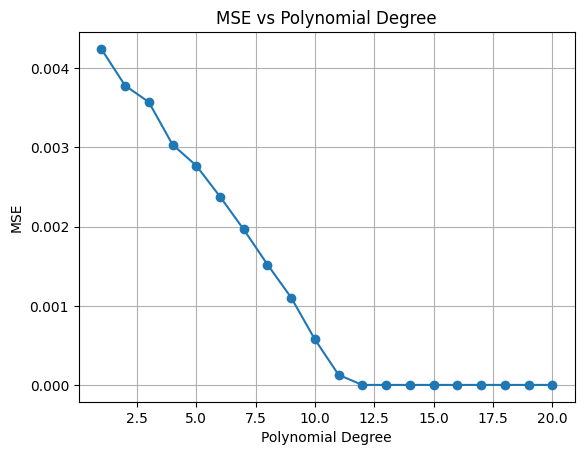

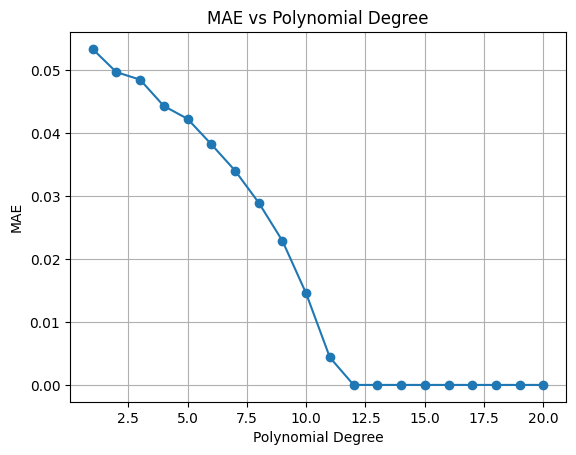

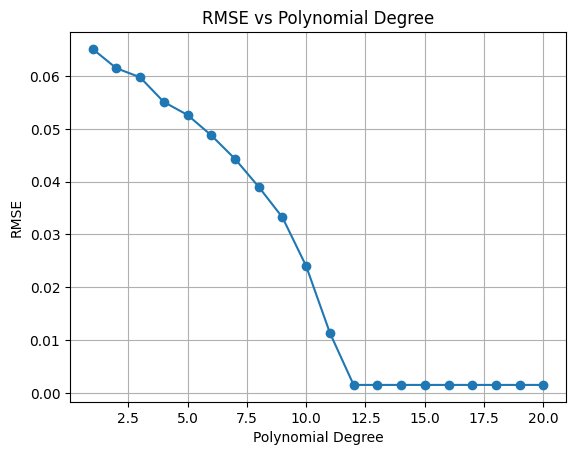

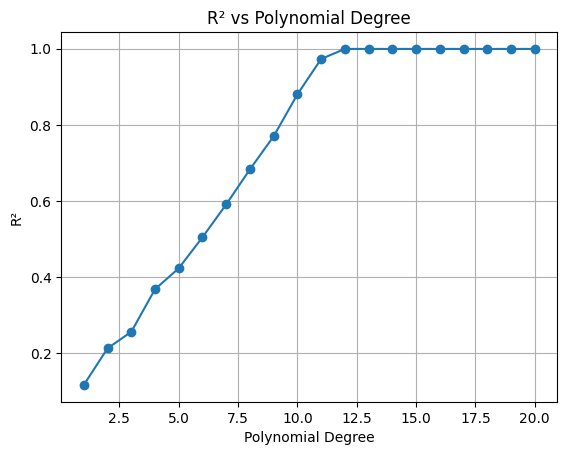

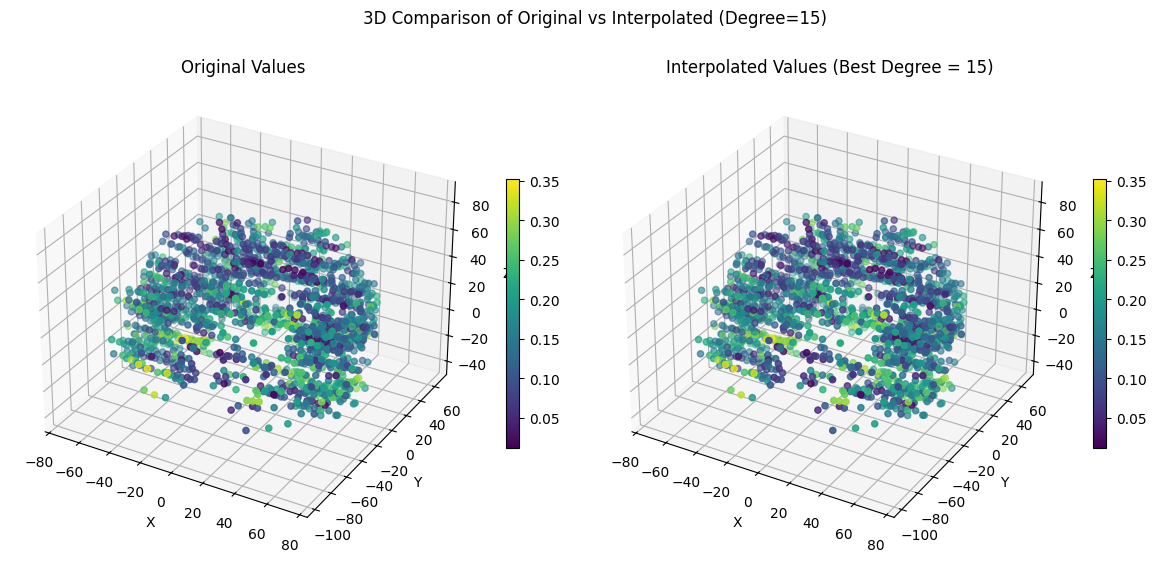

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import ttest_rel
from numpy.polynomial import chebyshev as T
from mpl_toolkits.mplot3d import Axes3D

# --------------------------
# 1. Data Loading
# --------------------------
coords = np.load('coords.npy')
band_powers = np.load('band_powers.npy', allow_pickle=True).item()
band = 'Delta'
band_values = np.array(band_powers[band])

# --------------------------
# 2. Chebyshev Interpolation
# --------------------------
def build_design_matrix(coords, degree, mins, maxs):
    n = coords.shape[0]
    A = np.zeros((n, (degree + 1) ** 3))
    for i in range(n):
        norm_pt = 2 * (coords[i] - mins) / (maxs - mins) - 1
        vx = T.chebvander(norm_pt[0], degree)[0]
        vy = T.chebvander(norm_pt[1], degree)[0]
        vz = T.chebvander(norm_pt[2], degree)[0]
        A[i, :] = np.kron(np.kron(vx, vy), vz)
    return A

def interpolate(coords, values, new_coords, degree=5):
    mins = np.min(coords, axis=0)
    maxs = np.max(coords, axis=0)
    A_train = build_design_matrix(coords, degree, mins, maxs)
    coeffs = np.linalg.lstsq(A_train, values, rcond=None)[0]
    A_new = build_design_matrix(new_coords, degree, mins, maxs)
    return A_new.dot(coeffs)

# --------------------------
# 3. Metrics & Evaluation
# --------------------------
def calculate_metrics(pred, true):
    mse = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, pred)
    return {'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R²': r2}

# --------------------------
# 4. Degree Sweep Experiment
# --------------------------
degrees = np.arange(1, 21)
mse_list, mae_list, rmse_list, r2_list = [],[],[],[]
t_stat_list, p_val_list = [],[]

for d in degrees:
    preds = interpolate(coords, band_values, coords, degree=d)
    metrics = calculate_metrics(preds, band_values)
    t_stat, p_val = ttest_rel(band_values, preds)

    mse_list.append(metrics['MSE'])
    mae_list.append(metrics['MAE'])
    rmse_list.append(metrics['RMSE'])
    r2_list.append(metrics['R²'])
    t_stat_list.append(t_stat)
    p_val_list.append(p_val)

# --------------------------
# 5. Visualization: Metrics vs Degree
# --------------------------
def plot_metric_vs_degree(values, metric_name):
    plt.figure()
    plt.plot(degrees, values, marker='o')
    plt.xlabel("Polynomial Degree")
    plt.ylabel(metric_name)
    plt.title(f"{metric_name} vs Polynomial Degree")
    plt.grid(True)
    plt.show()

plot_metric_vs_degree(mse_list, "MSE")
plot_metric_vs_degree(mae_list, "MAE")
plot_metric_vs_degree(rmse_list, "RMSE")
plot_metric_vs_degree(r2_list, "R²")


# --------------------------
# 6. 3D Visualization (choose best degree)
# --------------------------
best_degree = degrees[np.argmin(mse_list)]
best_preds = interpolate(coords, band_values, coords, degree=best_degree)

fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=band_values, cmap='viridis')
ax1.set_title(f'Original Values')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
fig.colorbar(sc1, ax=ax1, shrink=0.5)

ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=best_preds, cmap='viridis')
ax2.set_title(f'Interpolated Values (Best Degree = {best_degree})')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
fig.colorbar(sc2, ax=ax2, shrink=0.5)

plt.suptitle(f'3D Comparison of Original vs Interpolated (Degree={best_degree})')
plt.tight_layout()
plt.show()
